# Détection de communautés sur le dataset Brexit avec le Ψ-score

Ce notebook applique l'algorithme de clustering hiérarchique basé sur le **Ψ-score** (Giovanidis et al., 2021)  
au dataset **BrexitFollowers**, en suivant la même structure que le notebook PageRank/PPR.

---

## Pourquoi travailler sur des sous-graphes ?

Le graphe complet contient **7 589 nœuds** et **532 459 arêtes**.  
Le Ψ-score nécessite de calculer, pour chaque nœud `i`, un vecteur d'influence `q_i` de taille `n`,  
ce qui revient à résoudre `n` systèmes linéaires par itérations de puissance.  
La matrice résultante `R` est donc de taille **n × n**, soit 57 millions de valeurs pour le graphe entier.

De plus, l'algorithme de clustering est hiérarchique agglomératif : à chaque étape,  
il cherche la paire de communautés connectées minimisant `Δσ`, ce qui est en **O(k²)** en nombre de communautés.

**Stratégie adoptée** : on extrait un **sous-graphe des Top-K nœuds par degré**,  
ce qui conserve les nœuds les plus influents (hubs) et garde le graphe dense et connexe.  
On teste plusieurs tailles (50, 100, 200) pour observer la scalabilité de l'algorithme.

## 1. Imports

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms.community import modularity as nx_modularity

# Si psi-score n'est pas installé, décommenter la ligne suivante :
# !pip install git+https://github.com/NouamaneA/psi-score.git --ignore-requires-python -q

import scipy.sparse as sp
from psi_score import PsiScore
import data as dt

## 2. Chargement du dataset Brexit

In [2]:
bre = dt.BrexitFollowers(root="data/Brexit")
graph_directed = bre.to_networkx()   # DiGraph (dirigé)
graph = graph_directed.to_undirected()  # on travaille en non-dirigé pour le clustering (au cas ou)

print(f"Graphe complet : {bre.n} nœuds, {bre.m} arêtes")
print(f"Opinions disponibles : {set(nx.get_node_attributes(graph, 'max_opinion').values())}")

Graphe complet : 7589 nœuds, 532459 arêtes
Opinions disponibles : {'remain', 'neutral', 'leave'}


## 3. Construction du sous-graphe

On sélectionne les **Top-K nœuds par degré** dans le graphe non-dirigé.  
Ces nœuds sont les plus connectés (hubs), ce qui garantit que le sous-graphe est dense et reflète bien la structure de la communauté.

> **Note** : augmenter `K` améliore la représentativité mais augmente fortement le temps de calcul.  
> Commencez avec `K=50` pour un test rapide, puis montez à 100 ou 200.

In [3]:
# Paramètre principal
K = 100   # <-- modifier ici : 50 (rapide), 100, 200 ... (plus c'est grand plus c'est long) 


top_nodes = sorted(graph.nodes(), key=lambda n: graph.degree(n), reverse=True)[:K]
subgraph = graph.subgraph(top_nodes).copy()

# Vérifier la connexité (le Ψ-score est défini sur un graphe connexe)
if not nx.is_connected(subgraph):
    # On garde la plus grande composante connexe
    largest_cc = max(nx.connected_components(subgraph), key=len)
    subgraph = subgraph.subgraph(largest_cc).copy()
    print(f"Sous-graphe non connexe → on garde la plus grande composante : {subgraph.number_of_nodes()} nœuds")
else:
    print(f"Sous-graphe connexe")

print(f"Sous-graphe retenu : {subgraph.number_of_nodes()} nœuds, {subgraph.number_of_edges()} arêtes")

# Ré-indexer les nœuds de 0 à N-1 pour simplifier les matrices
subgraph = nx.convert_node_labels_to_integers(subgraph, label_attribute="original_id")
N = subgraph.number_of_nodes()
print(f"Nœuds ré-indexés : 0 à {N-1}")

Sous-graphe connexe
Sous-graphe retenu : 100 nœuds, 1987 arêtes
Nœuds ré-indexés : 0 à 99


## 4. Visualisation du sous-graphe (opinions Brexit)

Chaque nœud est coloré selon son opinion majoritaire :  
bleu : **remain** - rouge : **leave** - noir : **neutral**

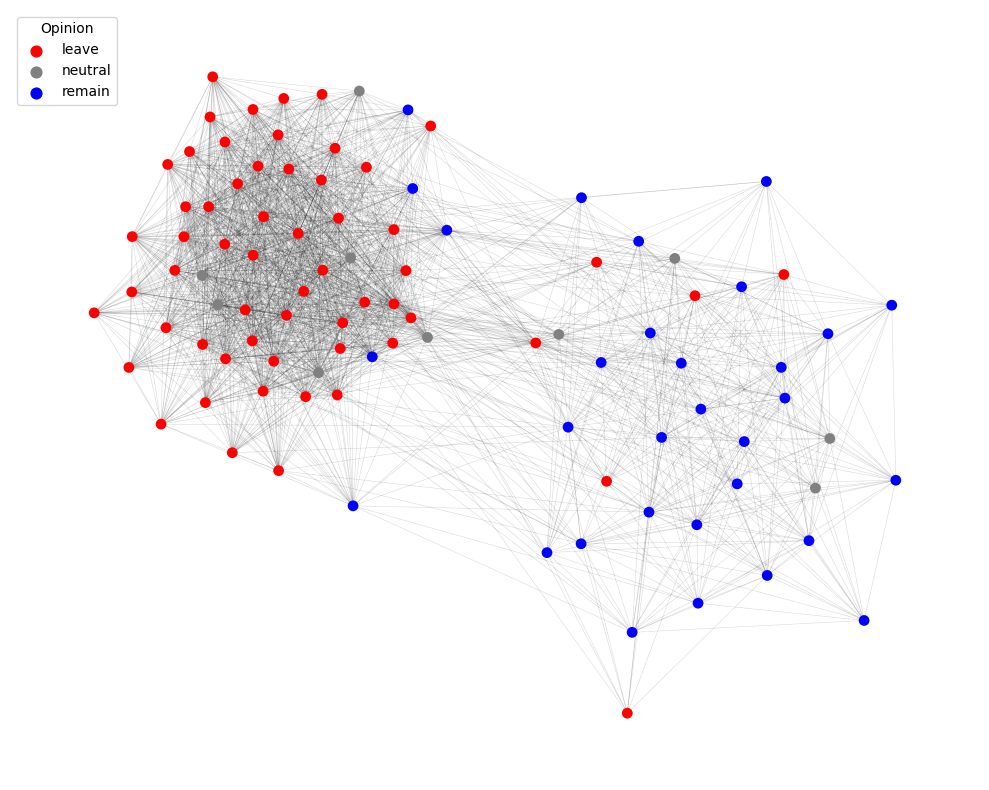

In [4]:
palette = {"leave": "red", "neutral": "gray", "remain": "blue"}
node_colors_opinion = [
    palette.get(subgraph.nodes[n].get("max_opinion", "neutral"), "gray")
    for n in subgraph.nodes()
]
pos = nx.spring_layout(subgraph, seed=42)
plt.figure(figsize=(10, 8))
nx.draw_networkx_edges(subgraph, pos, alpha=0.15, width=0.4)
nx.draw_networkx_nodes(subgraph, pos, node_size=60,
                       node_color=node_colors_opinion, linewidths=0)
for label, color in palette.items():
    plt.scatter([], [], c=color, label=label, s=60)
plt.legend(title="Opinion", loc="upper left")
plt.axis("off")
plt.tight_layout()
plt.savefig("CD_op.pdf", format="pdf", bbox_inches="tight")
plt.show()

## 5. Calcul de la matrice Ψ-score

Le Ψ-score généralise PageRank en modélisant les flux d'information sur un réseau social.  
Pour chaque nœud `i`, on calcule le vecteur `q_i` : l'influence de `i` sur le Wall de chaque autre nœud.

La matrice `R[i, j] = q_i[j]` encode donc toutes les influences croisées.

> **Cas homogène** : avec `λ = μ = 1` pour tous les nœuds,  
> le Ψ-score coïncide avec PageRank (Theorem 5 de l'article étudié).  
> C'est le même point de départ que l'algorithme C_PPR (Article Robust Hierarchical PPR) utilisé dans le notebook précédent.

In [5]:
print(f"Calcul du Ψ-score sur {N} nœuds : ")
print("résolution de N systèmes par itérations de puissance (peut prendre plusieurs secondes si N est grand)")

nodes = list(subgraph.nodes())
n = len(nodes)

# Taux de posting/re-posting uniformes : cas homogène equivalent au PageRank
lambdas = [1.0] * n
mus     = [1.0] * n

# Format d'adjacence attendu par psi-score
adjacency = {v: list(subgraph.neighbors(v)) for v in nodes}

psiscore = PsiScore(solver='power_nf', max_iter=500, tol=1e-4)
psiscore.fit(adjacency, lambdas, mus, qs=nodes)

# Assemblage de la matrice R
R = np.array([psiscore.Q[i] for i in nodes])

print(f"\nMatrice R calculée : shape = {R.shape}")
print(f"Min={R.min():.4f}, Max={R.max():.4f}, Moyenne={R.mean():.4f}")

 51% (51 of 100) |###########            | Elapsed Time: 0:00:00 ETA:   0:00:00

Calcul du Ψ-score sur 100 nœuds : 
résolution de N systèmes par itérations de puissance (peut prendre plusieurs secondes si N est grand)


100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:000:00



Matrice R calculée : shape = (100, 100)
Min=0.0001, Max=0.5081, Moyenne=0.0100


## 6. Algorithme de clustering Ψ-score

Reprise directe de `psi_algo_robust.py` — on recopie ici les fonctions clés  
pour que le notebook soit autonome.

L'algorithme fusionne itérativement les paires de communautés **connectées** qui minimisent `delta σ`,  
une mesure de divergence d'opinion pondérée par la taille des communautés.  
On retient la partition qui maximise la **modularité** au fil des fusions.

In [6]:
# Fonctions utilitaires

def community_opinion(R, C):
    """Vecteur d'opinion moyen d'une communauté C."""
    return R[list(C), :].mean(axis=0)

def community_distance(R, C1, C2, d):
    """Distance Ψ entre deux communautés (pondérée par les degrés)."""
    p1 = community_opinion(R, C1)
    p2 = community_opinion(R, C2)
    diff = p1 - p2
    return np.sqrt((diff ** 2 / d).sum())

def delta_sigma(R, C1, C2, d):
    """Critère de fusion : gain de variance inter-communauté pondéré."""
    n = R.shape[0]
    dist = community_distance(R, C1, C2, d)
    weight = (len(C1) * len(C2)) / (len(C1) + len(C2))
    return (1 / n) * weight * dist ** 2

def are_connected(A, C1, C2):
    """Vérifie s'il existe au moins une arête entre C1 et C2."""
    sub = A[np.ix_(list(C1), list(C2))]
    if sp.issparse(sub):
        return sub.nnz > 0
    return sub.any()

def modularity(G, communities):
    return nx_modularity(G, communities)


# Algorithme principal

def psi_clustering(A, G, R, verbose=True):
    """
    Clustering hiérarchique agglomératif guidé par le Ψ-score.
    
    À chaque étape :
      1. Trouver la paire (Ci, Cj) connectée qui minimise Δσ.
      2. Fusionner Ci et Cj.
      3. Calculer la modularité → garder la meilleure partition.
    """
    N = A.shape[0]
    degrees = np.array(A.sum(axis=1)).flatten()
    degrees[degrees == 0] = 1  # éviter la division par zéro

    communities = [{i} for i in range(N)]
    best_partition = communities.copy()
    best_Q = -np.inf
    history = []
    step = 0

    while len(communities) > 1:
        best_ds = float("inf")
        best_pair = None

        for i in range(len(communities)):
            for j in range(i + 1, len(communities)):
                if not are_connected(A, communities[i], communities[j]):
                    continue
                ds = delta_sigma(R, communities[i], communities[j], degrees)
                if ds < best_ds:
                    best_ds = ds
                    best_pair = (i, j)

        if best_pair is None:
            break

        i, j = best_pair
        C_new = communities[i] | communities[j]
        communities = [c for k, c in enumerate(communities) if k not in (i, j)]
        communities.append(C_new)

        Q = modularity(G, communities)
        history.append((step, len(communities), Q))

        if Q > best_Q:
            best_Q = Q
            best_partition = [c.copy() for c in communities]

        if verbose and step % 10 == 0:
            print(f"  Étape {step:3d} | {len(communities):3d} communautés | Q = {Q:.4f}")

        step += 1

    print(f"\n Terminé en {step} fusions.")
    print(f" Meilleure modularité Q = {best_Q:.4f} : {len(best_partition)} communautés")
    return best_partition, history


print("Fonctions chargées")

Fonctions chargées


## 7. Exécution du clustering

In [7]:
# Matrice d'adjacence sparse du sous-graphe
A_sub = nx.to_scipy_sparse_array(subgraph, format='csr')

print(f"Lancement du clustering Ψ-score sur {N} nœuds...\n")
communities_psi, history = psi_clustering(A_sub, subgraph, R, verbose=True)

print(f"\nRécapitulatif des communautés détectées ({len(communities_psi)}) :")
for i, c in enumerate(communities_psi):
    print(f"  Communauté {i} : {len(c)} nœuds")

Lancement du clustering Ψ-score sur 100 nœuds...

  Étape   0 |  99 communautés | Q = -0.0114
  Étape  10 |  89 communautés | Q = -0.0102
  Étape  20 |  79 communautés | Q = 0.0009
  Étape  30 |  69 communautés | Q = 0.0206
  Étape  40 |  59 communautés | Q = 0.0553
  Étape  50 |  49 communautés | Q = 0.0775
  Étape  60 |  39 communautés | Q = 0.1091
  Étape  70 |  29 communautés | Q = 0.1291
  Étape  80 |  19 communautés | Q = 0.1597
  Étape  90 |   9 communautés | Q = 0.2081

 Terminé en 99 fusions.
 Meilleure modularité Q = 0.2391 : 3 communautés

Récapitulatif des communautés détectées (3) :
  Communauté 0 : 1 nœuds
  Communauté 1 : 65 nœuds
  Communauté 2 : 34 nœuds


## 9. Évolution de la modularité au fil des fusions

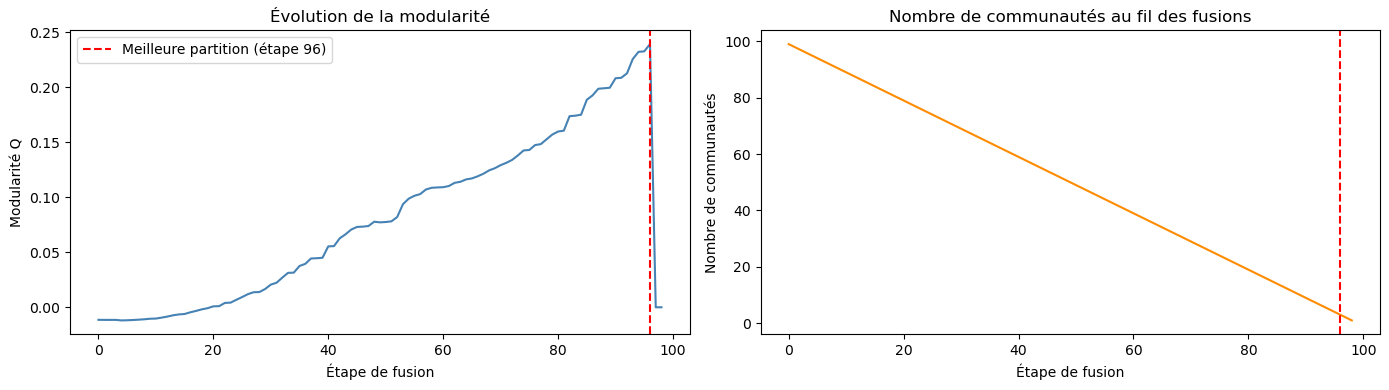

In [8]:
steps, n_comms, Q_vals = zip(*history)  # Separe les tuples de history en 3 séquences (steps, nb communautés, Q)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Modularité
axes[0].plot(steps, Q_vals, color="steelblue", linewidth=1.5)
best_step = steps[np.argmax(Q_vals)]
axes[0].axvline(best_step, color="red", linestyle="--", label=f"Meilleure partition (étape {best_step})")
axes[0].set_xlabel("Étape de fusion")
axes[0].set_ylabel("Modularité Q")
axes[0].set_title("Évolution de la modularité")
axes[0].legend()

# Nombre de communautés
axes[1].plot(steps, n_comms, color="darkorange", linewidth=1.5)
axes[1].axvline(best_step, color="red", linestyle="--")
axes[1].set_xlabel("Étape de fusion")
axes[1].set_ylabel("Nombre de communautés")
axes[1].set_title("Nombre de communautés au fil des fusions")

plt.tight_layout()
plt.show()

## 10. Visualisation des communautés détectées

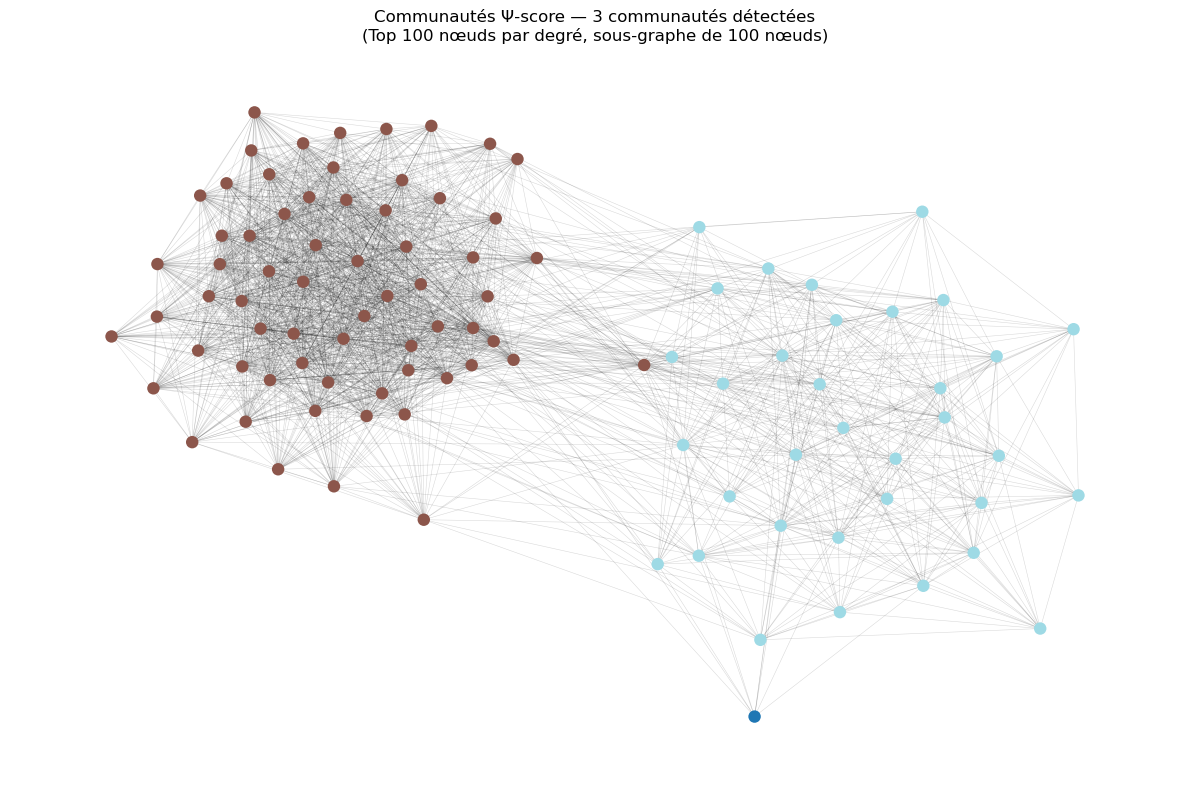

In [9]:
# Couleurs des communautés
node_color_map = {}
for idx, community in enumerate(communities_psi):
    for node in community:
        node_color_map[node] = idx

colors_comm = [node_color_map[n] for n in subgraph.nodes()]

plt.figure(figsize=(12, 8))
nx.draw_networkx_edges(subgraph, pos, alpha=0.15, width=0.4)
nx.draw_networkx_nodes(subgraph, pos,
                       node_color=colors_comm,
                       cmap=plt.cm.tab20,
                       node_size=80,
                       linewidths=0)
plt.title(f"Communautés Ψ-score — {len(communities_psi)} communautés détectées\n"
          f"(Top {K} nœuds par degré, sous-graphe de {N} nœuds)")
plt.axis("off")
plt.tight_layout()
plt.show()

## 11. Comparaison opinions réelles vs communautés détectées

On superpose les communautés détectées (contours) avec les opinions réelles (couleurs),  
pour voir si le Ψ-score regroupe bien les nœuds de même opinion.

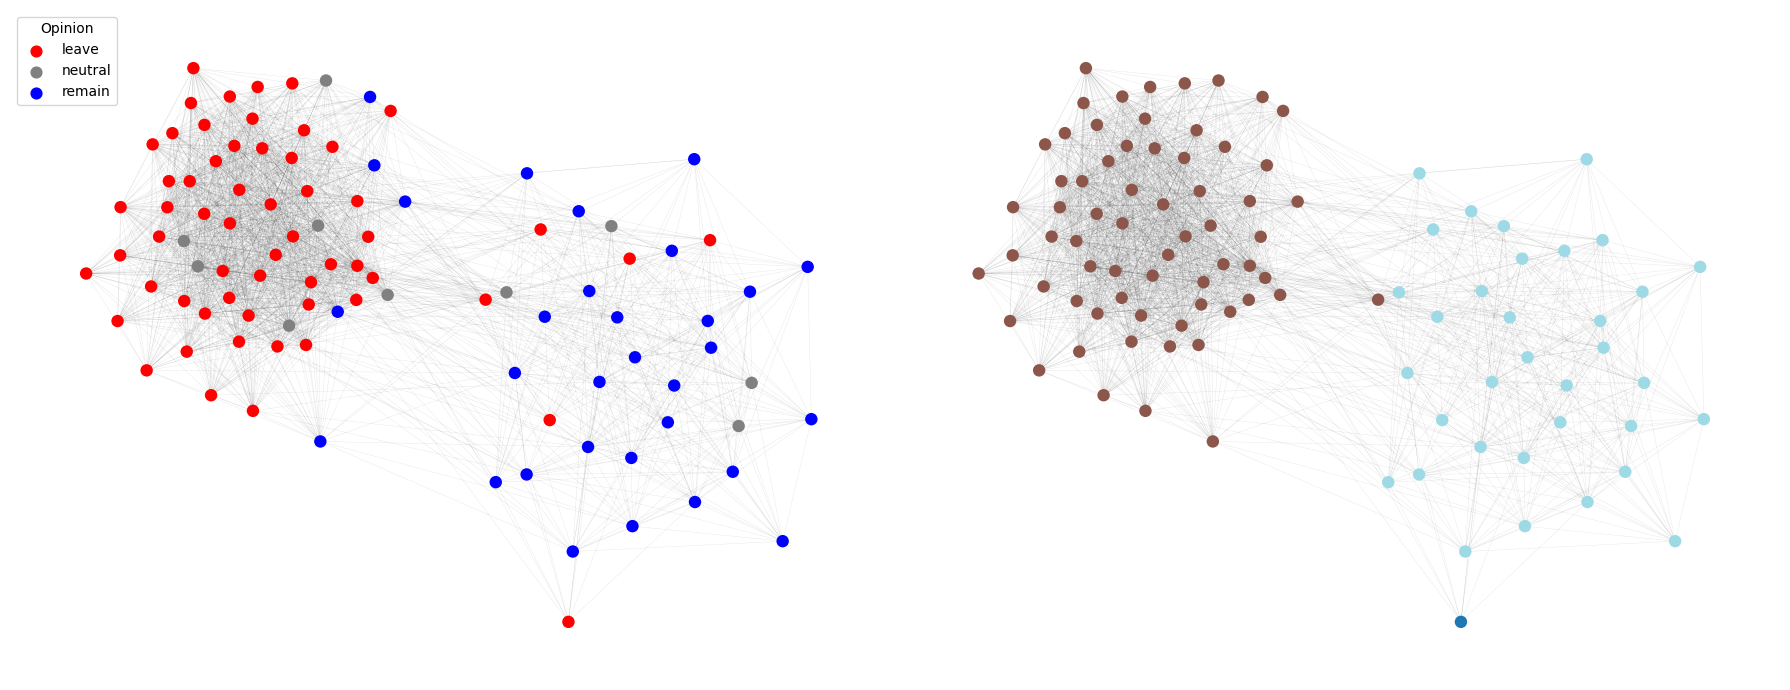

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Gauche : opinions réelles
nx.draw_networkx_edges(subgraph, pos, ax=axes[0], alpha=0.1, width=0.3)
nx.draw_networkx_nodes(subgraph, pos, ax=axes[0],
                       node_color=node_colors_opinion,
                       node_size=80, linewidths=0)
for label, color in palette.items():
    axes[0].scatter([], [], c=color, label=label, s=60)
axes[0].legend(title="Opinion", loc="upper left")
axes[0].axis("off")

# Droite : communautés Ψ-score
nx.draw_networkx_edges(subgraph, pos, ax=axes[1], alpha=0.1, width=0.3)
nx.draw_networkx_nodes(subgraph, pos, ax=axes[1],
                       node_color=colors_comm,
                       cmap=plt.cm.tab20,
                       node_size=80, linewidths=0)
axes[1].axis("off")

plt.tight_layout()
plt.savefig("CD_psi.pdf", format="pdf", bbox_inches="tight")
plt.show()

## 12. Analyse des opinions par communauté détectée

Pour chaque communauté, on calcule la distribution des opinions (remain / leave / neutral)  
afin de quantifier la cohérence entre structure de réseau et opinion politique.

            Taille  remain  leave  neutral Opinion dominante
Communauté                                                  
0                1       0      1        0             leave
1               65       5     54        6             leave
2               34      26      4        4            remain


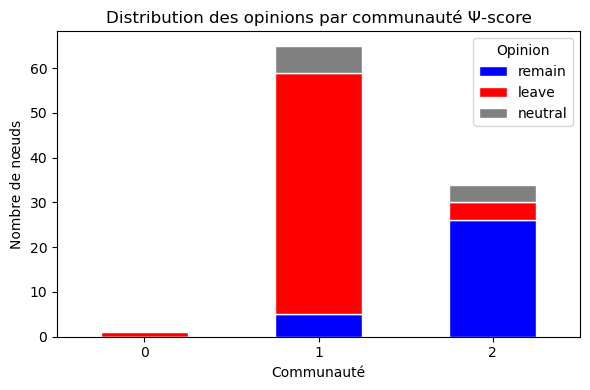

In [11]:
import pandas as pd

rows = []
for idx, community in enumerate(communities_psi):
    opinions = [subgraph.nodes[n].get("max_opinion", "neutral") for n in community]
    counts = {"remain": 0, "leave": 0, "neutral": 0}
    for op in opinions:
        counts[op] = counts.get(op, 0) + 1
    dominant = max(counts, key=counts.get)
    rows.append({
        "Communauté": idx,
        "Taille": len(community),
        "remain": counts["remain"],
        "leave": counts["leave"],
        "neutral": counts["neutral"],
        "Opinion dominante": dominant
    })

df = pd.DataFrame(rows).set_index("Communauté")
print(df.to_string())

# Stacked bar
df[["remain", "leave", "neutral"]].plot(
    kind="bar", stacked=True,
    color=["blue", "red", "gray"],
    figsize=(max(6, len(communities_psi)), 4),
    edgecolor="white"
)
plt.title("Distribution des opinions par communauté Ψ-score")
plt.xlabel("Communauté")
plt.ylabel("Nombre de nœuds")
plt.xticks(rotation=0)
plt.legend(title="Opinion")
plt.tight_layout()
plt.show()

## 13. Test sur différentes tailles de sous-graphe

On compare la modularité et le nombre de communautés détectées selon `K`  
pour mesurer la scalabilité de l'algorithme.

> précison : Cette cellule peut prendre plusieurs minutes selon les valeurs de `K_values`.

In [12]:
K_values = [50, 100, 150]  # ajouter 200, 300 (si le temps le permet)

results = []

for k_size in K_values:
    print(f"K = {k_size} nœuds")

    # Sous-graphe
    top_k = sorted(graph.nodes(), key=lambda n: graph.degree(n), reverse=True)[:k_size]
    sg = graph.subgraph(top_k).copy()
    if not nx.is_connected(sg):
        largest = max(nx.connected_components(sg), key=len)
        sg = sg.subgraph(largest).copy()
    sg = nx.convert_node_labels_to_integers(sg)
    n_sg = sg.number_of_nodes()

    # Ψ-score
    adj_k = {v: list(sg.neighbors(v)) for v in sg.nodes()}
    lam_k = [1.0] * n_sg
    mu_k  = [1.0] * n_sg
    psi_k = PsiScore(solver='power_nf', max_iter=500, tol=1e-4)
    psi_k.fit(adj_k, lam_k, mu_k, qs=list(sg.nodes()))
    R_k = np.array([psi_k.Q[i] for i in sg.nodes()])

    # Clustering
    A_k = nx.to_scipy_sparse_array(sg, format='csr')
    comm_k, hist_k = psi_clustering(A_k, sg, R_k, verbose=False)

    best_Q_k = max(h[2] for h in hist_k) if hist_k else None
    results.append({
        "K": k_size,
        "Nœuds retenus": n_sg,
        "Communautés": len(comm_k),
        "Modularité max": round(best_Q_k, 4) if best_Q_k else "N/A"
    })

df_results = pd.DataFrame(results).set_index("K")
print("\n Récapitulatif ")
print(df_results.to_string())

 36% (18 of 50) |########                | Elapsed Time: 0:00:00 ETA:   0:00:00

K = 50 nœuds


100% (50 of 50) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00
 26% (26 of 100) |#####                  | Elapsed Time: 0:00:00 ETA:   0:00:00


 Terminé en 49 fusions.
 Meilleure modularité Q = 0.1247 : 2 communautés
K = 100 nœuds


100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:000:00



 Terminé en 99 fusions.
 Meilleure modularité Q = 0.2391 : 3 communautés
K = 150 nœuds


100% (150 of 150) |######################| Elapsed Time: 0:00:00 Time:  0:00:000:00



 Terminé en 149 fusions.
 Meilleure modularité Q = 0.2390 : 2 communautés

 Récapitulatif 
     Nœuds retenus  Communautés  Modularité max
K                                              
50              50            2          0.1247
100            100            3          0.2391
150            150            2          0.2390


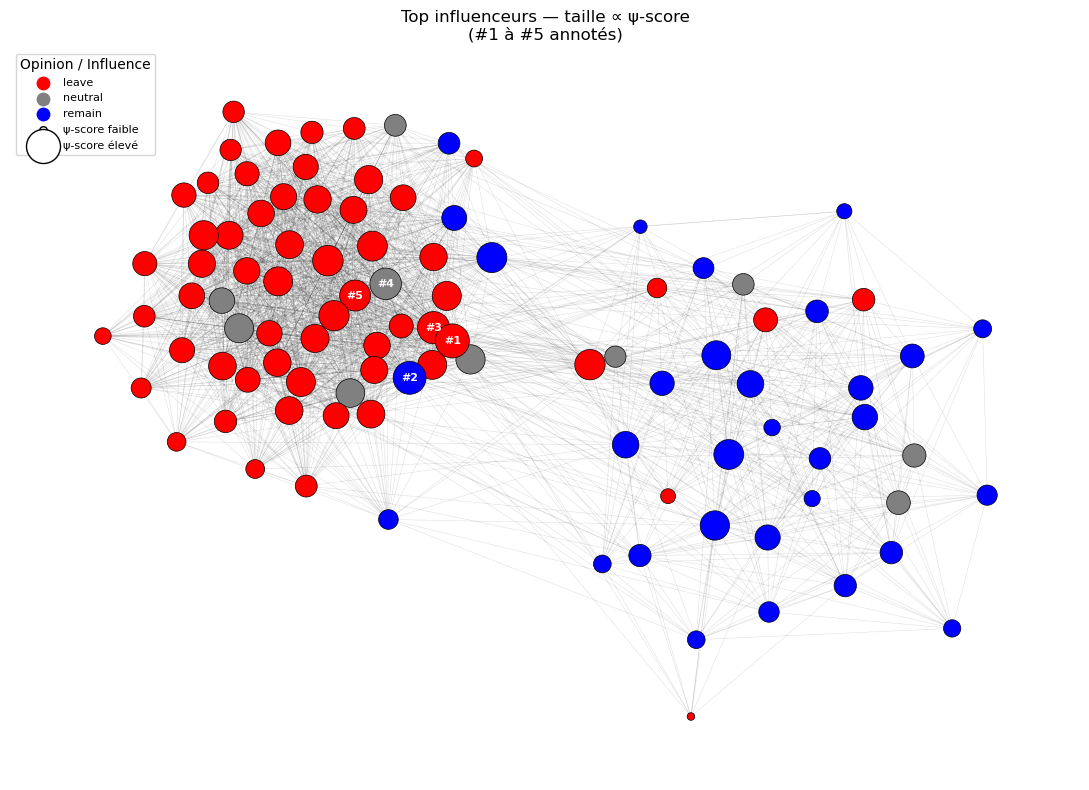

fig_top_influenceurs.pdf sauvegardé
Traitement K = 50 nœuds... 

100% (50 of 50) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00



 Terminé en 49 fusions.
 Meilleure modularité Q = 0.1247 : 2 communautés
OK — 17.5s | Q=0.125 | 2 communautés
Traitement K = 100 nœuds... 

100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:000:00



 Terminé en 99 fusions.
 Meilleure modularité Q = 0.2391 : 3 communautés
OK — 129.4s | Q=0.239 | 3 communautés
Traitement K = 150 nœuds... 

100% (150 of 150) |######################| Elapsed Time: 0:00:00 Time:  0:00:000:00



 Terminé en 149 fusions.
 Meilleure modularité Q = 0.2390 : 2 communautés
OK — 436.0s | Q=0.239 | 2 communautés

Récapitulatif :
     Nœuds  Communautés  Modularité  Temps (s)
K                                             
50      50            2      0.1247      17.48
100    100            3      0.2391     129.43
150    150            2      0.2390     435.98


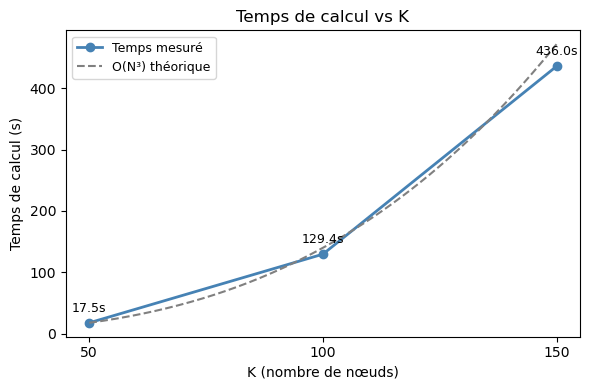

fig_scalabilite_temps.pdf sauvegardé


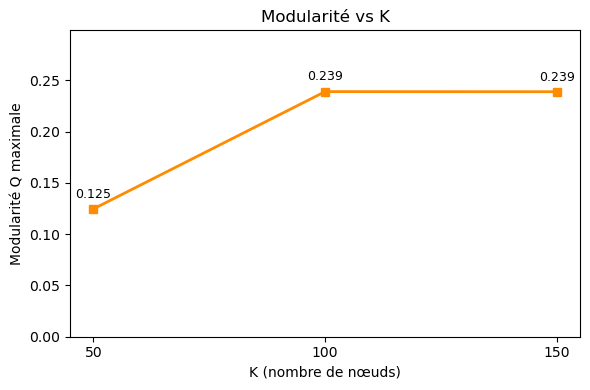

fig_scalabilite_modularite.pdf sauvegardé


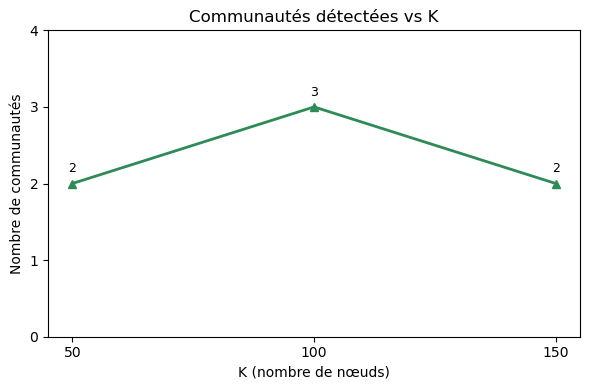

fig_scalabilite_communautes.pdf sauvegardé


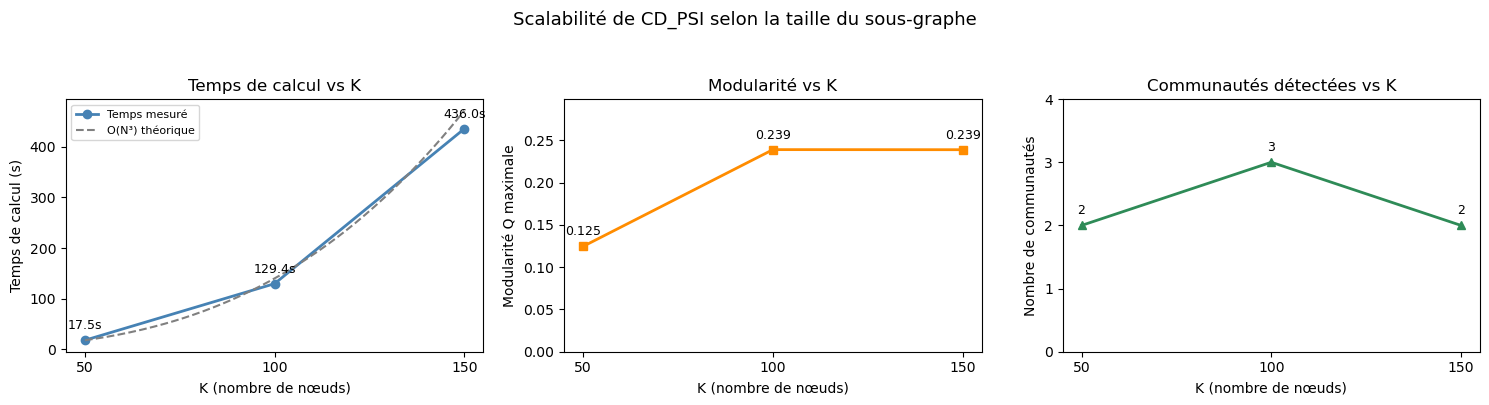

fig_scalabilite_combinee.pdf sauvegardé


In [16]:
import matplotlib.patches as mpatches
import time
import pandas as pd



# Top influenceurs : taille des nœuds proportionnelle au psi-score

palette = {"leave": "red", "neutral": "gray", "remain": "blue"}
node_colors_opinion = [
    palette.get(subgraph.nodes[n].get("max_opinion", "neutral"), "gray")
    for n in subgraph.nodes()
]

psi_min, psi_max = psi_scores.min(), psi_scores.max()
node_sizes = 30 + 570 * (psi_scores - psi_min) / (psi_max - psi_min + 1e-12)

fig, ax = plt.subplots(figsize=(11, 8))
nx.draw_networkx_edges(subgraph, pos, ax=ax, alpha=0.12, width=0.4)
nx.draw_networkx_nodes(subgraph, pos, ax=ax,
                       node_color=node_colors_opinion,
                       node_size=node_sizes,
                       linewidths=0.5,
                       edgecolors="black")

for node in top5:
    x, y = pos[node]
    ax.annotate(f"#{list(top5).index(node)+1}",
                xy=(x, y), fontsize=8, fontweight="bold",
                ha="center", va="center", color="white")

for label, color in palette.items():
    ax.scatter([], [], c=color, s=80, label=label)
for val, label in [(psi_min, "faible"), (psi_max, "élevé")]:
    size = 30 + 570 * (val - psi_min) / (psi_max - psi_min + 1e-12)
    ax.scatter([], [], c="white", edgecolors="black", s=size, label=f"ψ-score {label}")
ax.legend(loc="upper left", fontsize=8, title="Opinion / Influence")
ax.set_title("Top influenceurs — taille ∝ ψ-score\n(#1 à #5 annotés)")
ax.axis("off")
plt.tight_layout()
plt.savefig("fig_top_influenceurs.pdf", format="pdf", bbox_inches="tight")
plt.show()
plt.close()

print("fig_top_influenceurs.pdf sauvegardé")



# temps de calcul

K_values = [50, 100, 150]   # ajouter d'autres valeurs pour tester +

results = []

for k_size in K_values:
    print(f"Traitement K = {k_size} nœuds...", end=" ", flush=True)
    t_start = time.time()

    top_k = sorted(graph.nodes(), key=lambda n: graph.degree(n), reverse=True)[:k_size]
    sg = graph.subgraph(top_k).copy()
    if not nx.is_connected(sg):
        largest = max(nx.connected_components(sg), key=len)
        sg = sg.subgraph(largest).copy()
    sg = nx.convert_node_labels_to_integers(sg)
    n_sg = sg.number_of_nodes()

    adj_k = {v: list(sg.neighbors(v)) for v in sg.nodes()}
    lam_k = [1.0] * n_sg
    mu_k  = [1.0] * n_sg
    psi_k = PsiScore(solver='power_nf', max_iter=500, tol=1e-4)
    psi_k.fit(adj_k, lam_k, mu_k, qs=list(sg.nodes()))
    R_k = np.array([psi_k.Q[i] for i in sg.nodes()])

    A_k = nx.to_scipy_sparse_array(sg, format='csr')
    comm_k, hist_k = psi_clustering(A_k, sg, R_k, verbose=False)

    t_elapsed = time.time() - t_start
    best_Q_k = max(h[2] for h in hist_k) if hist_k else 0

    results.append({
        "K": k_size,
        "Nœuds": n_sg,
        "Communautés": len(comm_k),
        "Modularité": round(best_Q_k, 4),
        "Temps (s)": round(t_elapsed, 2)
    })
    print(f"OK — {t_elapsed:.1f}s | Q={best_Q_k:.3f} | {len(comm_k)} communautés")

df_scale = pd.DataFrame(results).set_index("K")
print("\nRécapitulatif :")
print(df_scale.to_string())

ks     = df_scale.index.tolist()
times  = df_scale["Temps (s)"].tolist()
colors = ["steelblue", "darkorange", "seagreen"]

# Temps de calcul + courbe O(N^3) théorique 
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ks, times, marker="o", color=colors[0], linewidth=2, label="Temps mesuré")

# Courbe O(N^3) normalisée sur le premier point
k_arr = np.linspace(ks[0], ks[-1], 200)
t_theo = times[0] * (k_arr / ks[0]) ** 3
ax.plot(k_arr, t_theo, linestyle="--", color="gray", linewidth=1.5, label="O(N³) théorique")

ax.set_xlabel("K (nombre de nœuds)")
ax.set_ylabel("Temps de calcul (s)")
ax.set_title("Temps de calcul vs K")
ax.set_xticks(ks)
ax.legend(fontsize=9)
for k, t in zip(ks, times):
    ax.annotate(f"{t:.1f}s", (k, t), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("fig_scalabilite_temps.pdf", format="pdf", bbox_inches="tight")
plt.show()
plt.close()
print("fig_scalabilite_temps.pdf sauvegardé")

# Modularité 
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ks, df_scale["Modularité"], marker="s", color=colors[1], linewidth=2)
ax.set_xlabel("K (nombre de nœuds)")
ax.set_ylabel("Modularité Q maximale")
ax.set_title("Modularité vs K")
ax.set_xticks(ks)
ax.set_ylim(0, max(df_scale["Modularité"]) * 1.25)
for k, q in zip(ks, df_scale["Modularité"]):
    ax.annotate(f"{q:.3f}", (k, q), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("fig_scalabilite_modularite.pdf", format="pdf", bbox_inches="tight")
plt.show()
plt.close()
print("fig_scalabilite_modularite.pdf sauvegardé")

# Nombre de communautés ─
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ks, df_scale["Communautés"], marker="^", color=colors[2], linewidth=2)
ax.set_xlabel("K (nombre de nœuds)")
ax.set_ylabel("Nombre de communautés")
ax.set_title("Communautés détectées vs K")
ax.set_xticks(ks)
ax.set_ylim(0, max(df_scale["Communautés"]) + 1)   # axe Y depuis 0
ax.set_yticks(range(0, max(df_scale["Communautés"]) + 2))
for k, c in zip(ks, df_scale["Communautés"]):
    ax.annotate(str(c), (k, c), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("fig_scalabilite_communautes.pdf", format="pdf", bbox_inches="tight")
plt.show()
plt.close()
print("fig_scalabilite_communautes.pdf sauvegardé")

# (les 3 ensemble)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(ks, times, marker="o", color=colors[0], linewidth=2, label="Temps mesuré")
axes[0].plot(k_arr, t_theo, linestyle="--", color="gray", linewidth=1.5, label="O(N³) théorique")
axes[0].set_xlabel("K (nombre de nœuds)")
axes[0].set_ylabel("Temps de calcul (s)")
axes[0].set_title("Temps de calcul vs K")
axes[0].set_xticks(ks)
axes[0].legend(fontsize=8)
for k, t in zip(ks, times):
    axes[0].annotate(f"{t:.1f}s", (k, t), textcoords="offset points",
                     xytext=(0, 8), ha="center", fontsize=9)

axes[1].plot(ks, df_scale["Modularité"], marker="s", color=colors[1], linewidth=2)
axes[1].set_xlabel("K (nombre de nœuds)")
axes[1].set_ylabel("Modularité Q maximale")
axes[1].set_title("Modularité vs K")
axes[1].set_xticks(ks)
axes[1].set_ylim(0, max(df_scale["Modularité"]) * 1.25)
for k, q in zip(ks, df_scale["Modularité"]):
    axes[1].annotate(f"{q:.3f}", (k, q), textcoords="offset points",
                     xytext=(0, 8), ha="center", fontsize=9)

axes[2].plot(ks, df_scale["Communautés"], marker="^", color=colors[2], linewidth=2)
axes[2].set_xlabel("K (nombre de nœuds)")
axes[2].set_ylabel("Nombre de communautés")
axes[2].set_title("Communautés détectées vs K")
axes[2].set_xticks(ks)
axes[2].set_ylim(0, max(df_scale["Communautés"]) + 1)
axes[2].set_yticks(range(0, max(df_scale["Communautés"]) + 2))
for k, c in zip(ks, df_scale["Communautés"]):
    axes[2].annotate(str(c), (k, c), textcoords="offset points",
                     xytext=(0, 8), ha="center", fontsize=9)

fig.suptitle("Scalabilité de CD_PSI selon la taille du sous-graphe",
             fontsize=13, y=1.0)
plt.tight_layout(rect=[0, 0, 1, 0.95])   
plt.savefig("fig_scalabilite_combinee.pdf", format="pdf", bbox_inches="tight")
plt.show()
plt.close()
print("fig_scalabilite_combinee.pdf sauvegardé")